# Perceptron : Basic Foundation Block of the Neural Networks.

In [7]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

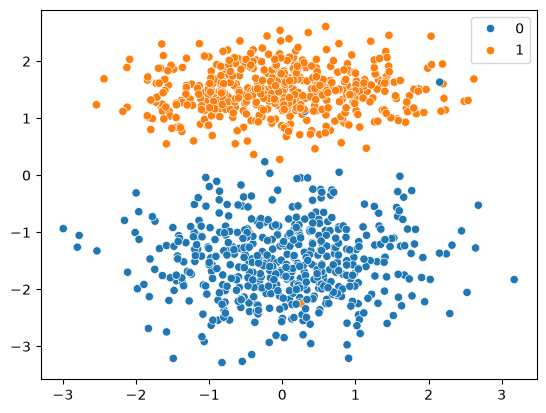

In [3]:
X, y = make_classification(n_samples=1000, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, class_sep=1.5, random_state=0)
sns.scatterplot(x=X[:, 0], y = X[:, 1], hue=y)
plt.show()

In [9]:
def step(i:float) -> int:
    return 1 if i>=0 else 0

### Basic Perceptron idea

In [10]:
class perceptron:
    def __init__(self, epochs: int = 1000, learning_rate:float = 0.01):
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self, X: np.ndarray | pd.DataFrame, y: np.ndarray):

        X = np.insert(X, 0, 1, axis=1)
        weights = np.ones(X.shape[1])

        for i in range(self.epochs):
            idx = np.random.randint(0, X.shape[0])
            y_pred = step(np.dot(X[idx], weights))
            weights += self.learning_rate * (y[idx] - y_pred)* X[idx]

        self.coef_ = weights[1:]
        self.intercept_ = weights[0]
    
    def predict(self, X_test: np.ndarray | pd.DataFrame) -> np.ndarray:
        return np.where((np.dot(X_test, self.coef_) + self.intercept_) >= 0, 1, 0)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [12]:
clf = perceptron()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test, y_pred)

0.9733333333333334

In [13]:
clf = Perceptron()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test, y_pred)

0.99

In [ ]:
or_data = pd.DataFrame({
    'input1' : [1,1,0,0],
    'input2' : [1,0,1,0],
    'output' : [1,1,1,0]
})
and_data = pd.DataFrame({
    'input1' : [1,1,0,0],
    'input2' : [1,0,1,0],
    'output' : [1,0,0,0]
})
xor_data = pd.DataFrame({
    'input1' : [1,1,0,0],
    'input2' : [1,0,1,0],
    'output' : [0,1,1,0]
})

(   input1  input2  output
 0       1       1       1
 1       1       0       1
 2       0       1       1
 3       0       0       0,
    input1  input2  output
 0       1       1       1
 1       1       0       0
 2       0       1       0
 3       0       0       0,
    input1  input2  output
 0       1       1       0
 1       1       0       1
 2       0       1       1
 3       0       0       0)

In [20]:
and_data

,input1,input2,output
0,1,1,1
1,1,0,0
2,0,1,0
3,0,0,0


<Axes: xlabel='input1', ylabel='input2'>

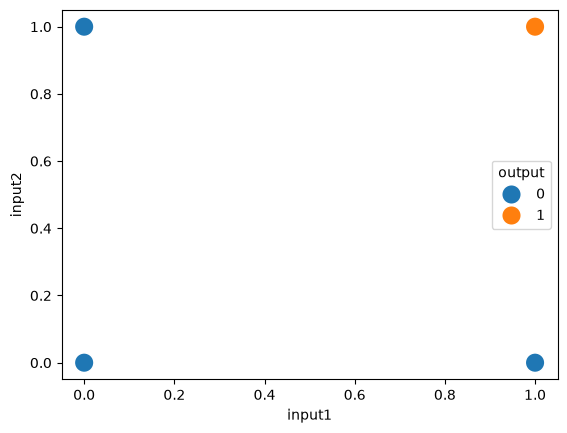

In [19]:
sns.scatterplot(x = and_data['input1'],y = and_data['input2'],hue=and_data['output'],s=200)

In [21]:
or_data

,input1,input2,output
0,1,1,1
1,1,0,1
2,0,1,1
3,0,0,0


<Axes: xlabel='input1', ylabel='input2'>

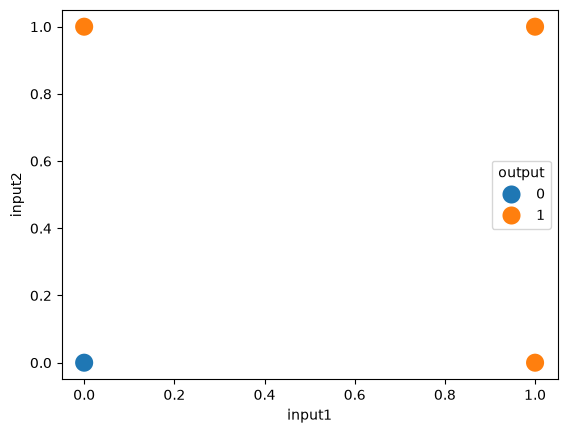

In [22]:
sns.scatterplot(x = or_data['input1'],y = or_data['input2'],hue=or_data['output'],s=200)

In [23]:
xor_data

,input1,input2,output
0,1,1,0
1,1,0,1
2,0,1,1
3,0,0,0


<Axes: xlabel='input1', ylabel='input2'>

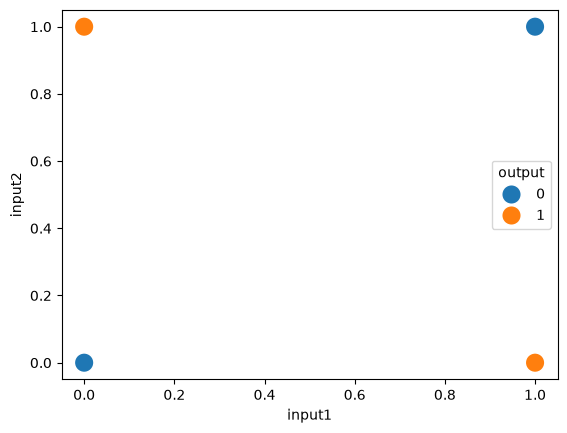

In [24]:
sns.scatterplot(x = xor_data['input1'],y = xor_data['input2'],hue=xor_data['output'],s=200)

In [26]:
clf1=Perceptron()
clf2=Perceptron()
clf3=Perceptron()

clf1.fit(and_data.iloc[:,0:2].values,and_data.iloc[:,-1].values)
clf2.fit(or_data.iloc[:,0:2].values,or_data.iloc[:,-1].values)
clf3.fit(xor_data.iloc[:,0:2].values,xor_data.iloc[:,-1].values)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


<Axes: >

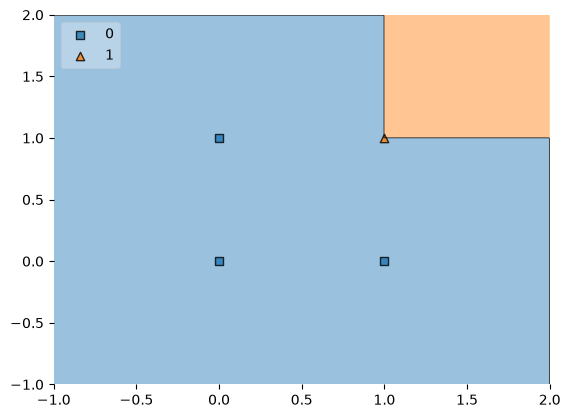

In [27]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(and_data.iloc[:,0:2].values,and_data.iloc[:,-1].values, clf=clf1, legend=2)

### AND points are correctly classified.

<Axes: >

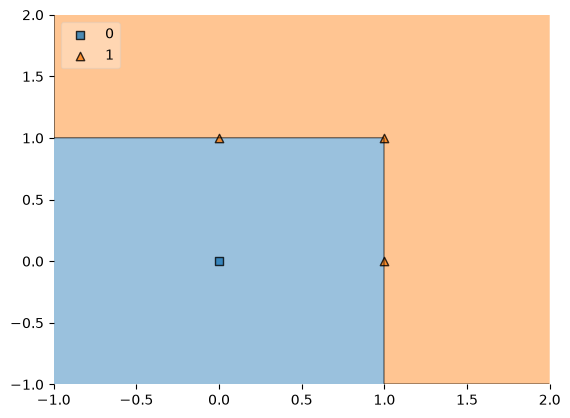

In [28]:
plot_decision_regions(or_data.iloc[:,0:2].values,or_data.iloc[:,-1].values, clf=clf2, legend=2)

### OR points are correctly classified.

<Axes: >

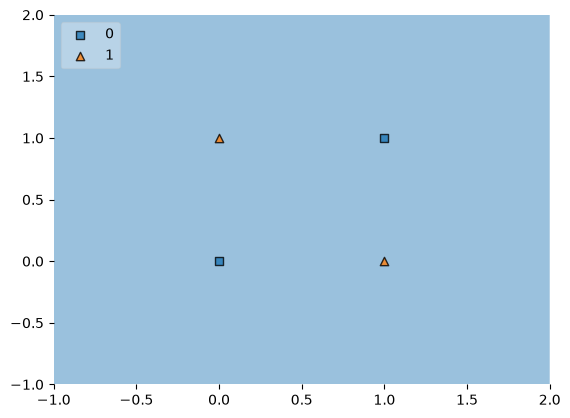

In [29]:
plot_decision_regions(xor_data.iloc[:,0:2].values,xor_data.iloc[:,-1].values, clf=clf3, legend=2)

### XOR points are not correctly classified.

### This tells that Perceptron is only for linear data not for non-linear data.